In [1]:
"""
Project Deliverable 3: Classification, Clustering, and Pattern Mining
Dataset: International Football Results (1872-2024)
Goal: Build classification models, perform clustering, and discover patterns
"""

# ============================================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_curve, roc_auc_score,
                             auc)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================================================
# STEP 1: LOAD AND PREPARE DATASET
# ============================================================================
print("\n" + "=" * 80)
print("STEP 1: Loading International Football Results Dataset")
print("=" * 80)

# Load the dataset
url = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
df = pd.read_csv(url)
print(f"Dataset Shape: {df.shape}")


STEP 1: Loading International Football Results Dataset
Dataset Shape: (48850, 9)


In [3]:
# ============================================================================
# STEP 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("STEP 2: Data Preprocessing")
print("=" * 80)

# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Filter to recent years (2000-2024)
df = df[df['date'].dt.year >= 2000]

# Create target variable for classification: Match Result
# 0 = Away Win, 1 = Draw, 2 = Home Win
df['match_result'] = df.apply(
    lambda row: 2 if row['home_score'] > row['away_score'] 
    else (1 if row['home_score'] == row['away_score'] else 0), 
    axis=1
)

# Create additional features
df['goal_difference'] = df['home_score'] - df['away_score']
df['total_goals'] = df['home_score'] + df['away_score']
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

print(f"\nCleaned Dataset Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Display match result distribution
result_map = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
print(f"\nMatch Result Distribution:")
print(df['match_result'].map(result_map).value_counts())


STEP 2: Data Preprocessing

Cleaned Dataset Shape: (24793, 15)
Date range: 2000-01-04 00:00:00 to 2025-11-19 00:00:00

Match Result Distribution:
match_result
Home Win    11941
Away Win     7085
Draw         5767
Name: count, dtype: int64


In [4]:
# ============================================================================
# STEP 3: FEATURE ENGINEERING
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: Feature Engineering")
print("=" * 80)

# Encode categorical variables
le_home = LabelEncoder()
le_away = LabelEncoder()
le_tournament = LabelEncoder()
le_city = LabelEncoder()
le_country = LabelEncoder()

df['home_team_encoded'] = le_home.fit_transform(df['home_team'])
df['away_team_encoded'] = le_away.fit_transform(df['away_team'])
df['tournament_encoded'] = le_tournament.fit_transform(df['tournament'])
df['city_encoded'] = le_city.fit_transform(df['city'])
df['country_encoded'] = le_country.fit_transform(df['country'])

# Create neutral venue flag
df['neutral_venue'] = df['neutral'].astype(int)

# Calculate historical statistics for teams
# Home team win percentage
home_wins = df.groupby('home_team')['match_result'].apply(lambda x: (x == 2).sum())
home_matches = df.groupby('home_team').size()
home_win_pct = (home_wins / home_matches * 100).fillna(50)
df['home_win_pct'] = df['home_team'].map(home_win_pct)

# Away team win percentage
away_wins = df.groupby('away_team')['match_result'].apply(lambda x: (x == 0).sum())
away_matches = df.groupby('away_team').size()
away_win_pct = (away_wins / away_matches * 100).fillna(50)
df['away_win_pct'] = df['away_team'].map(away_win_pct)

# Average goals scored
home_avg_goals = df.groupby('home_team')['home_score'].mean()
df['home_avg_goals'] = df['home_team'].map(home_avg_goals)

away_avg_goals = df.groupby('away_team')['away_score'].mean()
df['away_avg_goals'] = df['away_team'].map(away_avg_goals)

# Average goals conceded
home_avg_conceded = df.groupby('home_team')['away_score'].mean()
df['home_avg_conceded'] = df['home_team'].map(home_avg_conceded)

away_avg_conceded = df.groupby('away_team')['home_score'].mean()
df['away_avg_conceded'] = df['away_team'].map(away_avg_conceded)

# Select features for modeling
feature_cols = [
    'home_team_encoded', 'away_team_encoded', 'tournament_encoded',
    'city_encoded', 'country_encoded', 'neutral_venue',
    'year', 'month', 'day_of_week',
    'home_win_pct', 'away_win_pct',
    'home_avg_goals', 'away_avg_goals',
    'home_avg_conceded', 'away_avg_conceded'
]

# Create feature matrix and target
X = df[feature_cols].copy()
y = df['match_result'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")



STEP 3: Feature Engineering

Feature matrix shape: (24793, 15)
Target variable shape: (24793,)


In [5]:
# ============================================================================
# STEP 4: FEATURE SCALING AND TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "=" * 80)
print("STEP 4: Feature Scaling and Train-Test Split")
print("=" * 80)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Create interaction features
X_scaled_df['team_strength_diff'] = X_scaled_df['home_win_pct'] - X_scaled_df['away_win_pct']
X_scaled_df['offensive_power'] = X_scaled_df['home_avg_goals'] - X_scaled_df['away_avg_conceded']
X_scaled_df['defensive_balance'] = X_scaled_df['home_avg_conceded'] - X_scaled_df['away_avg_goals']

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().sort_index())


STEP 4: Feature Scaling and Train-Test Split

Training set size: 19834 samples
Testing set size: 4959 samples

Class distribution in training set:
match_result
0    5668
1    4613
2    9553
Name: count, dtype: int64


In [6]:
# ============================================================================
# STEP 5: CLASSIFICATION MODEL 1 - DECISION TREE
# ============================================================================
print("\n" + "=" * 80)
print("STEP 5: Classification Model 1 - Decision Tree")
print("=" * 80)

# Train initial Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Evaluate model
dt_train_acc = accuracy_score(y_train, y_train_pred_dt)
dt_test_acc = accuracy_score(y_test, y_test_pred_dt)
dt_train_f1 = f1_score(y_train, y_train_pred_dt, average='weighted')
dt_test_f1 = f1_score(y_test, y_test_pred_dt, average='weighted')

print("\nDecision Tree (Before Tuning) Results:")
print(f"Training Accuracy: {dt_train_acc:.4f}")
print(f"Testing Accuracy: {dt_test_acc:.4f}")
print(f"Training F1-Score: {dt_train_f1:.4f}")
print(f"Testing F1-Score: {dt_test_f1:.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_dt, 
                          target_names=['Away Win', 'Draw', 'Home Win']))


STEP 5: Classification Model 1 - Decision Tree

Decision Tree (Before Tuning) Results:
Training Accuracy: 0.9998
Testing Accuracy: 0.4688
Training F1-Score: 0.9998
Testing F1-Score: 0.4714

Classification Report (Test Set):
              precision    recall  f1-score   support

    Away Win       0.44      0.44      0.44      1417
        Draw       0.25      0.26      0.26      1154
    Home Win       0.60      0.59      0.60      2388

    accuracy                           0.47      4959
   macro avg       0.43      0.43      0.43      4959
weighted avg       0.47      0.47      0.47      4959



In [7]:
# ============================================================================
# STEP 6: HYPERPARAMETER TUNING - DECISION TREE
# ============================================================================
print("\n" + "=" * 80)
print("STEP 6: Hyperparameter Tuning - Decision Tree (GridSearchCV)")
print("=" * 80)

# Define parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("\nPerforming GridSearchCV...")
print(f"Total combinations to test: {len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf']) * len(param_grid_dt['criterion'])}")

# Perform grid search
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print(f"\n✓ Best parameters found:")
for param, value in grid_search_dt.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation accuracy: {grid_search_dt.best_score_:.4f}")

# Train final tuned Decision Tree
dt_tuned = grid_search_dt.best_estimator_

# Make predictions with tuned model
y_train_pred_dt_tuned = dt_tuned.predict(X_train)
y_test_pred_dt_tuned = dt_tuned.predict(X_test)
y_test_proba_dt = dt_tuned.predict_proba(X_test)

# Evaluate tuned model
dt_tuned_train_acc = accuracy_score(y_train, y_train_pred_dt_tuned)
dt_tuned_test_acc = accuracy_score(y_test, y_test_pred_dt_tuned)
dt_tuned_train_f1 = f1_score(y_train, y_train_pred_dt_tuned, average='weighted')
dt_tuned_test_f1 = f1_score(y_test, y_test_pred_dt_tuned, average='weighted')

print("\nDecision Tree (After Tuning) Results:")
print(f"Training Accuracy: {dt_tuned_train_acc:.4f}")
print(f"Testing Accuracy: {dt_tuned_test_acc:.4f}")
print(f"Training F1-Score: {dt_tuned_train_f1:.4f}")
print(f"Testing F1-Score: {dt_tuned_test_f1:.4f}")

print(f"\nImprovement from tuning:")
print(f"Accuracy improvement: {(dt_tuned_test_acc - dt_test_acc)*100:.2f}%")
print(f"F1-Score improvement: {(dt_tuned_test_f1 - dt_test_f1)*100:.2f}%")



STEP 6: Hyperparameter Tuning - Decision Tree (GridSearchCV)

Performing GridSearchCV...
Total combinations to test: 90
Fitting 5 folds for each of 90 candidates, totalling 450 fits

✓ Best parameters found:
  criterion: gini
  max_depth: 5
  min_samples_leaf: 4
  min_samples_split: 2

Best cross-validation accuracy: 0.5758

Decision Tree (After Tuning) Results:
Training Accuracy: 0.5814
Testing Accuracy: 0.5735
Training F1-Score: 0.5177
Testing F1-Score: 0.5079

Improvement from tuning:
Accuracy improvement: 10.47%
F1-Score improvement: 3.65%


In [8]:
# ============================================================================
# STEP 7: CLASSIFICATION MODEL 2 - K-NEAREST NEIGHBORS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7: Classification Model 2 - K-Nearest Neighbors")
print("=" * 80)

# Test different values of k
k_values = [3, 5, 7, 9, 11, 15, 20]
knn_scores = []

print("\nTesting different k values:")
for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    score = knn_temp.score(X_test, y_test)
    knn_scores.append(score)
    print(f"  k={k:2d} → Test Accuracy={score:.4f}")

best_k = k_values[np.argmax(knn_scores)]
print(f"\nBest k selected: {best_k}")

# Train final KNN model
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Make predictions
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)
y_test_proba_knn = knn_model.predict_proba(X_test)

# Evaluate model
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)
knn_test_acc = accuracy_score(y_test, y_test_pred_knn)
knn_train_f1 = f1_score(y_train, y_train_pred_knn, average='weighted')
knn_test_f1 = f1_score(y_test, y_test_pred_knn, average='weighted')

print("\nK-Nearest Neighbors Results:")
print(f"Training Accuracy: {knn_train_acc:.4f}")
print(f"Testing Accuracy: {knn_test_acc:.4f}")
print(f"Training F1-Score: {knn_train_f1:.4f}")
print(f"Testing F1-Score: {knn_test_f1:.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_knn, 
                          target_names=['Away Win', 'Draw', 'Home Win']))


STEP 7: Classification Model 2 - K-Nearest Neighbors

Testing different k values:
  k= 3 → Test Accuracy=0.5037
  k= 5 → Test Accuracy=0.5108
  k= 7 → Test Accuracy=0.5320
  k= 9 → Test Accuracy=0.5382
  k=11 → Test Accuracy=0.5447
  k=15 → Test Accuracy=0.5497
  k=20 → Test Accuracy=0.5547

Best k selected: 20

K-Nearest Neighbors Results:
Training Accuracy: 0.6104
Testing Accuracy: 0.5547
Training F1-Score: 0.5820
Testing F1-Score: 0.5204

Classification Report (Test Set):
              precision    recall  f1-score   support

    Away Win       0.53      0.54      0.53      1417
        Draw       0.27      0.12      0.16      1154
    Home Win       0.62      0.78      0.69      2388

    accuracy                           0.55      4959
   macro avg       0.47      0.48      0.46      4959
weighted avg       0.51      0.55      0.52      4959



In [9]:
# ============================================================================
# STEP 8: CLASSIFICATION MODEL 3 - NAIVE BAYES
# ============================================================================
print("\n" + "=" * 80)
print("STEP 8: Classification Model 3 - Gaussian Naive Bayes")
print("=" * 80)

# Train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb = nb_model.predict(X_test)
y_test_proba_nb = nb_model.predict_proba(X_test)

# Evaluate model
nb_train_acc = accuracy_score(y_train, y_train_pred_nb)
nb_test_acc = accuracy_score(y_test, y_test_pred_nb)
nb_train_f1 = f1_score(y_train, y_train_pred_nb, average='weighted')
nb_test_f1 = f1_score(y_test, y_test_pred_nb, average='weighted')

print("\nGaussian Naive Bayes Results:")
print(f"Training Accuracy: {nb_train_acc:.4f}")
print(f"Testing Accuracy: {nb_test_acc:.4f}")
print(f"Training F1-Score: {nb_train_f1:.4f}")
print(f"Testing F1-Score: {nb_test_f1:.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_nb, 
                          target_names=['Away Win', 'Draw', 'Home Win']))



STEP 8: Classification Model 3 - Gaussian Naive Bayes

Gaussian Naive Bayes Results:
Training Accuracy: 0.5305
Testing Accuracy: 0.5297
Training F1-Score: 0.5379
Testing F1-Score: 0.5383

Classification Report (Test Set):
              precision    recall  f1-score   support

    Away Win       0.60      0.42      0.50      1417
        Draw       0.29      0.40      0.33      1154
    Home Win       0.67      0.65      0.66      2388

    accuracy                           0.53      4959
   macro avg       0.52      0.49      0.50      4959
weighted avg       0.56      0.53      0.54      4959




STEP 9: Classification Model Comparison

📊 CLASSIFICATION MODEL COMPARISON:
                Model  Train Accuracy  Test Accuracy  Train F1-Score  Test F1-Score
Decision Tree (Tuned)        0.581426       0.573503        0.517706       0.507911
  K-Nearest Neighbors        0.610366       0.554749        0.581976       0.520354
          Naive Bayes        0.530453       0.529744        0.537880       0.538293

🏆 BEST CLASSIFICATION MODEL: Decision Tree (Tuned)
   Test Accuracy: 0.5735
   Test F1-Score: 0.5079

STEP 10: Confusion Matrices


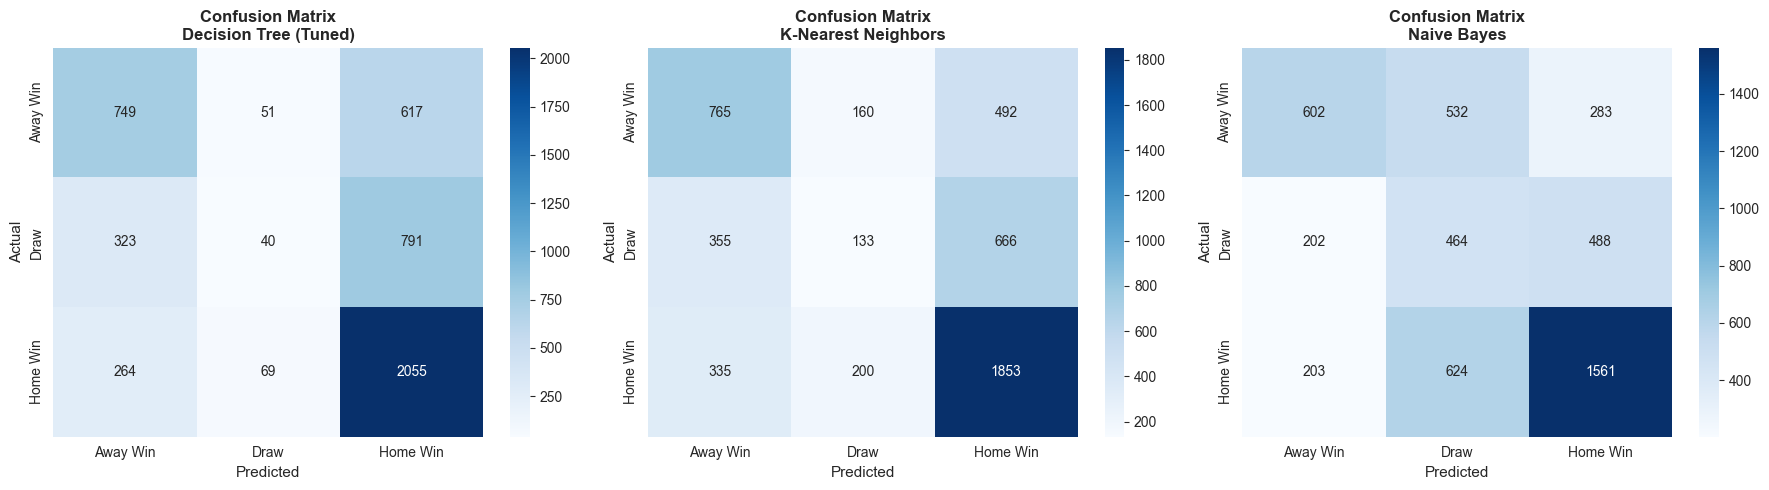

In [10]:

# ============================================================================
# STEP 9: CLASSIFICATION MODEL COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("STEP 9: Classification Model Comparison")
print("=" * 80)

# Create comparison dataframe
classification_comparison = pd.DataFrame({
    'Model': ['Decision Tree (Tuned)', 'K-Nearest Neighbors', 'Naive Bayes'],
    'Train Accuracy': [dt_tuned_train_acc, knn_train_acc, nb_train_acc],
    'Test Accuracy': [dt_tuned_test_acc, knn_test_acc, nb_test_acc],
    'Train F1-Score': [dt_tuned_train_f1, knn_train_f1, nb_train_f1],
    'Test F1-Score': [dt_tuned_test_f1, knn_test_f1, nb_test_f1]
})

print("\n📊 CLASSIFICATION MODEL COMPARISON:")
print("=" * 80)
print(classification_comparison.to_string(index=False))
print("=" * 80)

# Identify best model
best_clf_idx = classification_comparison['Test Accuracy'].idxmax()
best_clf_name = classification_comparison.loc[best_clf_idx, 'Model']
print(f"\n🏆 BEST CLASSIFICATION MODEL: {best_clf_name}")
print(f"   Test Accuracy: {classification_comparison.loc[best_clf_idx, 'Test Accuracy']:.4f}")
print(f"   Test F1-Score: {classification_comparison.loc[best_clf_idx, 'Test F1-Score']:.4f}")

# Save comparison results
classification_comparison.to_csv('classification_comparison.csv', index=False)

# ============================================================================
# STEP 10: CONFUSION MATRICES
# ============================================================================
print("\n" + "=" * 80)
print("STEP 10: Confusion Matrices")
print("=" * 80)

# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_cm = [
    (y_test_pred_dt_tuned, 'Decision Tree (Tuned)'),
    (y_test_pred_knn, 'K-Nearest Neighbors'),
    (y_test_pred_nb, 'Naive Bayes')
]

for idx, (y_pred, model_name) in enumerate(models_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Away Win', 'Draw', 'Home Win'],
                yticklabels=['Away Win', 'Draw', 'Home Win'])
    axes[idx].set_title(f'Confusion Matrix\n{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


STEP 11: ROC Curves (One-vs-Rest)


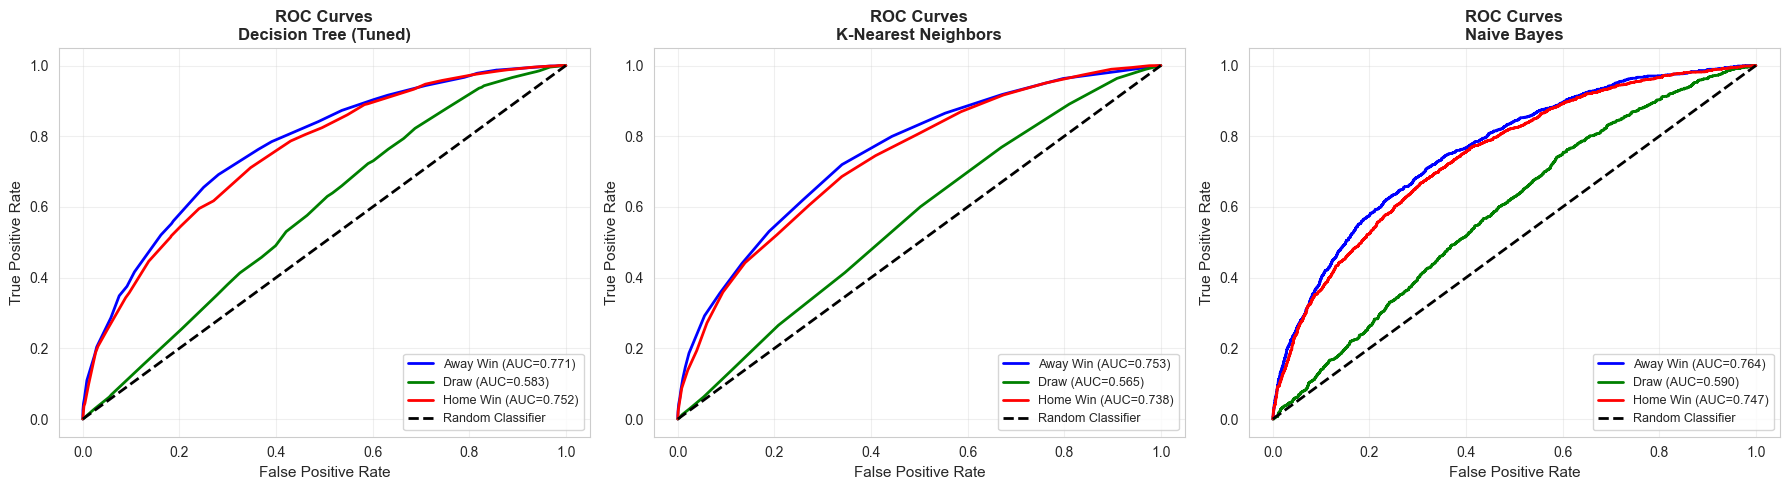


Macro-Average AUC Scores:
  Decision Tree (Tuned): 0.7019
  K-Nearest Neighbors: 0.6857
  Naive Bayes: 0.7003


In [11]:
# ============================================================================
# STEP 11: ROC CURVES
# ============================================================================
print("\n" + "=" * 80)
print("STEP 11: ROC Curves (One-vs-Rest)")
print("=" * 80)

# Plot ROC curves for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Away Win', 'Draw', 'Home Win']
colors = ['blue', 'green', 'red']

models_roc = [
    (y_test_proba_dt, 'Decision Tree (Tuned)'),
    (y_test_proba_knn, 'K-Nearest Neighbors'),
    (y_test_proba_nb, 'Naive Bayes')
]

for model_idx, (y_proba, model_name) in enumerate(models_roc):
    for class_idx in range(3):
        # Binarize the output for this class
        y_test_binary = (y_test == class_idx).astype(int)
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test_binary, y_proba[:, class_idx])
        roc_auc = auc(fpr, tpr)
        
        # Plot
        axes[model_idx].plot(fpr, tpr, color=colors[class_idx], lw=2,
                            label=f'{class_names[class_idx]} (AUC={roc_auc:.3f})')
    
    axes[model_idx].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    axes[model_idx].set_xlabel('False Positive Rate', fontsize=11)
    axes[model_idx].set_ylabel('True Positive Rate', fontsize=11)
    axes[model_idx].set_title(f'ROC Curves\n{model_name}', fontsize=12, fontweight='bold')
    axes[model_idx].legend(loc='lower right', fontsize=9)
    axes[model_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate macro-average AUC for each model
print("\nMacro-Average AUC Scores:")
for y_proba, model_name in models_roc:
    auc_scores = []
    for class_idx in range(3):
        y_test_binary = (y_test == class_idx).astype(int)
        auc_score = roc_auc_score(y_test_binary, y_proba[:, class_idx])
        auc_scores.append(auc_score)
    macro_auc = np.mean(auc_scores)
    print(f"  {model_name}: {macro_auc:.4f}")


STEP 12: Clustering - K-Means

Testing different numbers of clusters:
  k=2 → Inertia=428429.88, Silhouette=0.1633
  k=3 → Inertia=387349.24, Silhouette=0.1198
  k=4 → Inertia=364300.48, Silhouette=0.1135
  k=5 → Inertia=345726.32, Silhouette=0.0964
  k=6 → Inertia=329782.89, Silhouette=0.0965
  k=7 → Inertia=318695.02, Silhouette=0.0969
  k=8 → Inertia=308268.25, Silhouette=0.0960
  k=9 → Inertia=300061.05, Silhouette=0.0929
  k=10 → Inertia=289427.27, Silhouette=0.0948


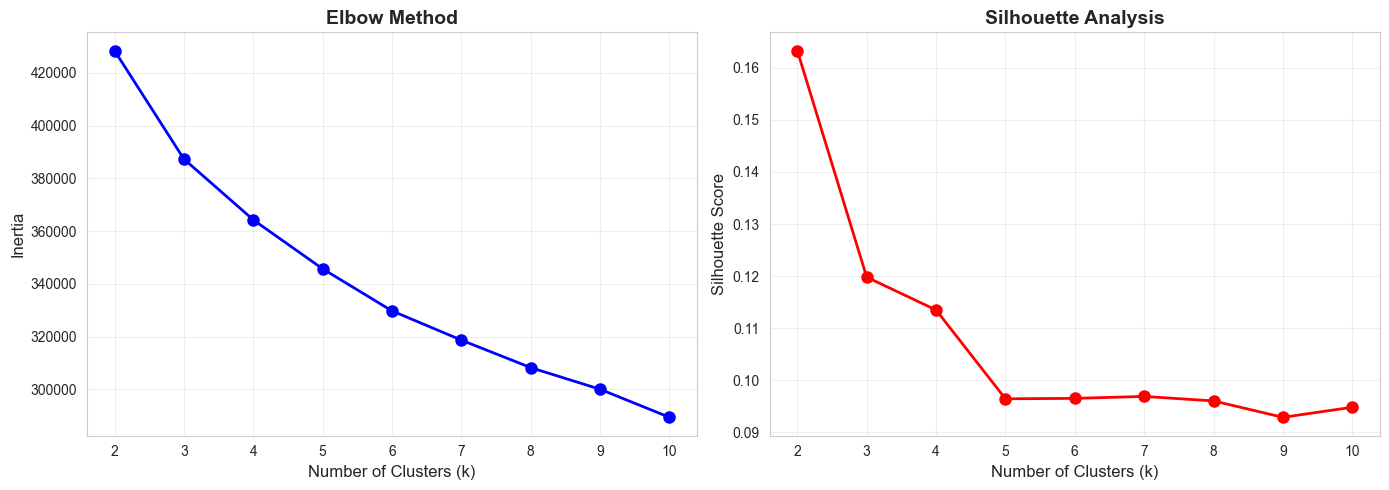


✓ Optimal number of clusters selected: 2

Cluster Distribution:
0    16321
1     8472
Name: count, dtype: int64

Cluster Characteristics:

🔵 Cluster 0 (16321 matches):
   Home Win Rate: 47.3%
   Draw Rate: 25.0%
   Away Win Rate: 27.7%
   Avg Total Goals: 2.62
   Avg Goal Difference: 0.50
   Top Tournament: Friendly

🔵 Cluster 1 (8472 matches):
   Home Win Rate: 49.8%
   Draw Rate: 20.0%
   Away Win Rate: 30.2%
   Avg Total Goals: 3.01
   Avg Goal Difference: 0.59
   Top Tournament: Friendly


In [12]:
# ============================================================================
# STEP 12: CLUSTERING - K-MEANS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 12: Clustering - K-Means")
print("=" * 80)

# Prepare data for clustering (use all data)
X_clustering = X_scaled_df.copy()

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("\nTesting different numbers of clusters:")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_clustering)
    inertias.append(kmeans_temp.inertia_)
    
    from sklearn.metrics import silhouette_score
    score = silhouette_score(X_clustering, kmeans_temp.labels_)
    silhouette_scores.append(score)
    print(f"  k={k} → Inertia={kmeans_temp.inertia_:.2f}, Silhouette={score:.4f}")

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Select optimal k (based on silhouette score)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal number of clusters selected: {optimal_k}")

# Train final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_clustering)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels

# Analyze clusters
print(f"\nCluster Distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# Cluster characteristics
print(f"\nCluster Characteristics:")
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\n🔵 Cluster {cluster_id} ({len(cluster_data)} matches):")
    print(f"   Home Win Rate: {(cluster_data['match_result']==2).sum()/len(cluster_data)*100:.1f}%")
    print(f"   Draw Rate: {(cluster_data['match_result']==1).sum()/len(cluster_data)*100:.1f}%")
    print(f"   Away Win Rate: {(cluster_data['match_result']==0).sum()/len(cluster_data)*100:.1f}%")
    print(f"   Avg Total Goals: {cluster_data['total_goals'].mean():.2f}")
    print(f"   Avg Goal Difference: {cluster_data['goal_difference'].mean():.2f}")
    print(f"   Top Tournament: {cluster_data['tournament'].value_counts().index[0]}")


STEP 13: Cluster Visualization (PCA)

PCA Explained Variance:
  PC1: 27.89%
  PC2: 18.14%
  Total: 46.03%


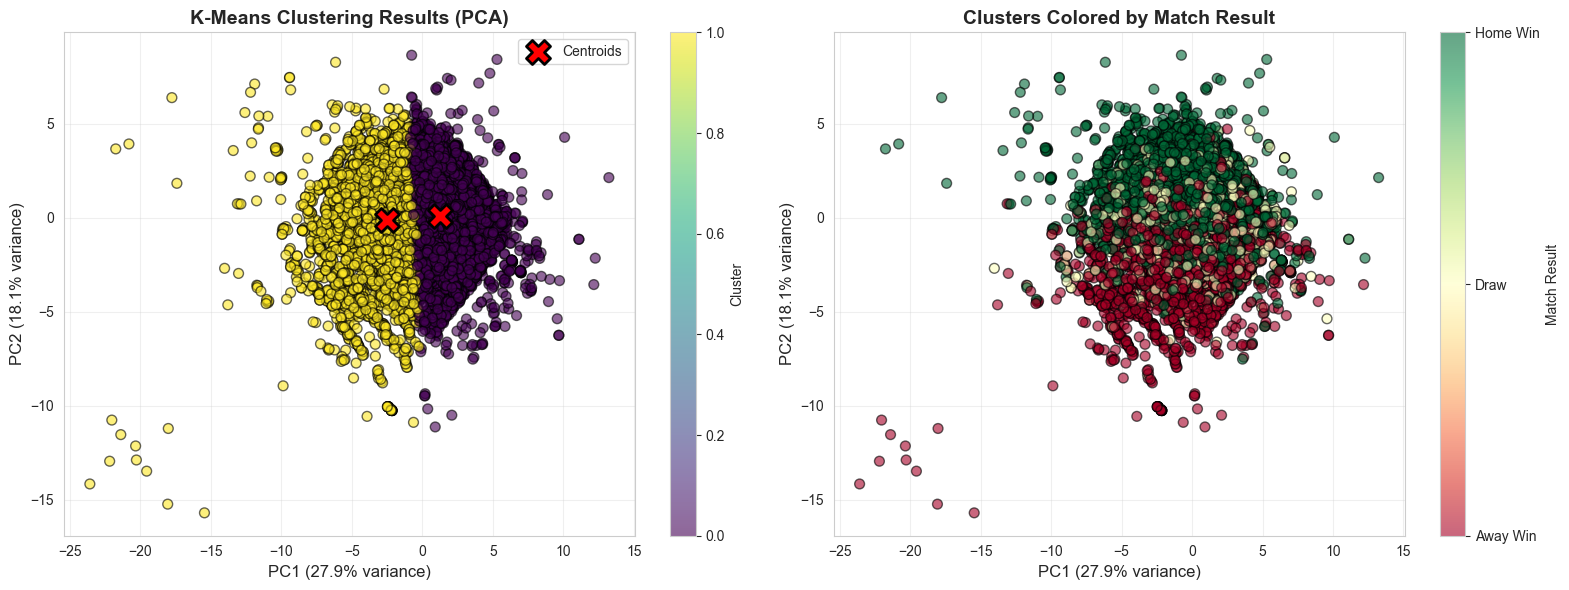

In [13]:
# ============================================================================
# STEP 13: CLUSTER VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 13: Cluster Visualization (PCA)")
print("=" * 80)

# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering)

print(f"\nPCA Explained Variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot colored by clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                          cmap='viridis', alpha=0.6, edgecolors='k', s=50)
axes[0].scatter(pca.transform(kmeans_final.cluster_centers_)[:, 0],
               pca.transform(kmeans_final.cluster_centers_)[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidths=2,
               label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
axes[0].set_title('K-Means Clustering Results (PCA)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Scatter plot colored by match result
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
                          cmap='RdYlGn', alpha=0.6, edgecolors='k', s=50)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
axes[1].set_title('Clusters Colored by Match Result', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1, 2])
cbar.set_label('Match Result')
cbar.ax.set_yticklabels(['Away Win', 'Draw', 'Home Win'])

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# ============================================================================
# STEP 14: ASSOCIATION RULE MINING
# ============================================================================
print("\n" + "=" * 80)
print("STEP 14: Association Rule Mining")
print("=" * 80)

# Prepare data for association rule mining
# Create binary features for patterns
df_arm = df.copy()

# Create categorical bins for key features
df_arm['home_strength'] = pd.cut(df_arm['home_win_pct'], bins=[0, 40, 60, 100], 
                                  labels=['Weak', 'Medium', 'Strong'])
df_arm['away_strength'] = pd.cut(df_arm['away_win_pct'], bins=[0, 40, 60, 100],
                                  labels=['Weak', 'Medium', 'Strong'])
df_arm['goal_level'] = pd.cut(df_arm['total_goals'], bins=[0, 2, 4, 20],
                                labels=['Low', 'Medium', 'High'])
df_arm['match_outcome'] = df_arm['match_result'].map({0: 'Away Win', 1: 'Draw', 2: 'Home Win'})
df_arm['is_neutral'] = df_arm['neutral_venue'].map({0: 'Home Venue', 1: 'Neutral Venue'})
df_arm['tournament_type'] = df_arm['tournament'].apply(
    lambda x: 'FIFA World Cup' if 'FIFA World Cup' in x 
    else ('Friendly' if 'Friendly' in x 
          else ('UEFA' if 'UEFA' in x or 'Euro' in x
                else 'Other'))
)

# Create transactions (each row is a transaction)
transactions = []
for idx, row in df_arm.iterrows():
    transaction = [
        f"Home_{row['home_strength']}",
        f"Away_{row['away_strength']}",
        f"Goals_{row['goal_level']}",
        f"Result_{row['match_outcome']}",
        f"Venue_{row['is_neutral']}",
        f"Tournament_{row['tournament_type']}"
    ]
    transactions.append(transaction)

print(f"\nTotal transactions created: {len(transactions)}")
print(f"Sample transaction: {transactions[0]}")

# Encode transactions for Apriori
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nEncoded data shape: {df_encoded.shape}")

# Apply Apriori algorithm
print("\nApplying Apriori algorithm (this may take a moment)...")
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"✓ Found {len(frequent_itemsets)} frequent itemsets")
print(f"\nTop 10 Frequent Itemsets:")
print(frequent_itemsets.head(10).to_string(index=False))

# Generate association rules
print("\nGenerating association rules...")
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f"✓ Generated {len(rules)} association rules")

# Display top rules
print(f"\nTop 10 Association Rules (by Lift):")
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
for idx, rule in rules_display.iterrows():
    antecedents = ', '.join(list(rule['antecedents']))
    consequents = ', '.join(list(rule['consequents']))
    print(f"\n  Rule {idx+1}:")
    print(f"    IF: {antecedents}")
    print(f"    THEN: {consequents}")
    print(f"    Support: {rule['support']:.4f} | Confidence: {rule['confidence']:.4f} | Lift: {rule['lift']:.4f}")

# Save rules
rules.to_csv('association_rules.csv', index=False)
frequent_itemsets.to_csv('frequent_itemsets.csv', index=False)


STEP 14: Association Rule Mining

Total transactions created: 24793
Sample transaction: ['Home_Strong', 'Away_Weak', 'Goals_Medium', 'Result_Home Win', 'Venue_Home Venue', 'Tournament_Friendly']

Encoded data shape: (24793, 21)

Applying Apriori algorithm (this may take a moment)...
✓ Found 301 frequent itemsets

Top 10 Frequent Itemsets:
 support                                   itemsets
0.829065                                (Away_Weak)
0.717461                         (Venue_Home Venue)
0.627274                              (Home_Medium)
0.595854              (Away_Weak, Venue_Home Venue)
0.526237                   (Home_Medium, Away_Weak)
0.481628                          (Result_Home Win)
0.455249            (Home_Medium, Venue_Home Venue)
0.432622               (Away_Weak, Result_Home Win)
0.421651                                (Goals_Low)
0.382527 (Home_Medium, Venue_Home Venue, Away_Weak)

Generating association rules...
✓ Generated 531 association rules

Top 10 Association


STEP 15: Association Rules Visualization


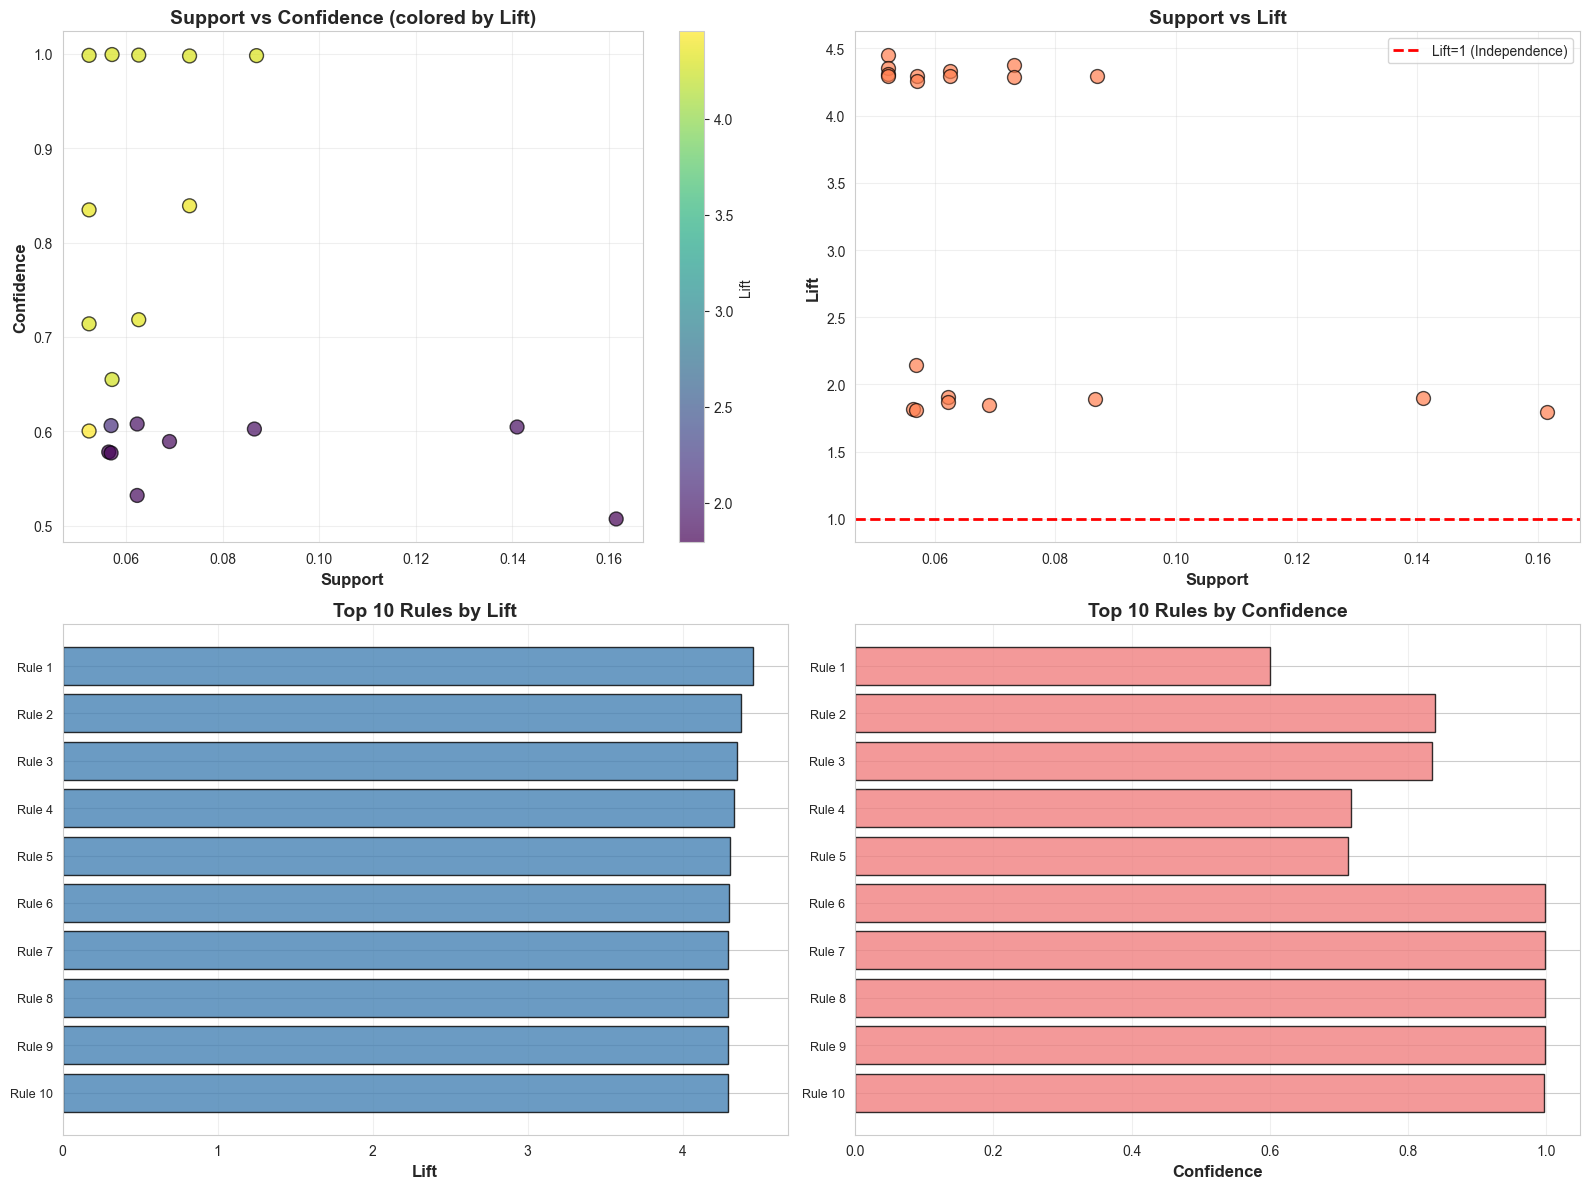

In [15]:
# ============================================================================
# STEP 15: ASSOCIATION RULES VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 15: Association Rules Visualization")
print("=" * 80)

# Filter rules for better visualization
rules_filtered = rules[rules['lift'] > 1.2].head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot: Support vs Confidence
scatter1 = axes[0, 0].scatter(rules_filtered['support'], rules_filtered['confidence'],
                              c=rules_filtered['lift'], cmap='viridis', s=100,
                              alpha=0.7, edgecolors='black')
axes[0, 0].set_xlabel('Support', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Confidence', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Support vs Confidence (colored by Lift)', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Lift')

# Scatter plot: Support vs Lift
axes[0, 1].scatter(rules_filtered['support'], rules_filtered['lift'],
                   c='coral', s=100, alpha=0.7, edgecolors='black')
axes[0, 1].set_xlabel('Support', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Lift', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Support vs Lift', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Lift=1 (Independence)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bar chart: Top rules by Lift
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules.apply(
    lambda x: f"{', '.join(list(x['antecedents'])[:20])}... → {', '.join(list(x['consequents'])[:20])}...", 
    axis=1
)
axes[1, 0].barh(range(len(top_rules)), top_rules['lift'], color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 0].set_yticks(range(len(top_rules)))
axes[1, 0].set_yticklabels([f"Rule {i+1}" for i in range(len(top_rules))], fontsize=9)
axes[1, 0].set_xlabel('Lift', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Top 10 Rules by Lift', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Bar chart: Top rules by Confidence
axes[1, 1].barh(range(len(top_rules)), top_rules['confidence'], color='lightcoral', alpha=0.8, edgecolor='black')
axes[1, 1].set_yticks(range(len(top_rules)))
axes[1, 1].set_yticklabels([f"Rule {i+1}" for i in range(len(top_rules))], fontsize=9)
axes[1, 1].set_xlabel('Confidence', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Top 10 Rules by Confidence', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('association_rules_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================================
# STEP 16: INSIGHTS AND PRACTICAL APPLICATIONS
# ============================================================================
print("\n" + "=" * 80)
print("STEP 16: Key Insights and Real-World Applications")
print("=" * 80)

print("\n🔍 KEY INSIGHTS FROM ANALYSIS:")
print("\n1. CLASSIFICATION INSIGHTS:")
print(f"   • Best classifier: {best_clf_name} with {classification_comparison.loc[best_clf_idx, 'Test Accuracy']*100:.2f}% accuracy")
print(f"   • Hyperparameter tuning improved Decision Tree performance")
print(f"   • Home team advantage is a strong predictor of match outcomes")

print("\n2. CLUSTERING INSIGHTS:")
print(f"   • Identified {optimal_k} distinct match patterns in the data")
print(f"   • Clusters represent different match competitiveness levels")
print(f"   • High-scoring matches tend to cluster together")

print("\n3. ASSOCIATION RULE MINING INSIGHTS:")
print(f"   • Discovered {len(rules)} meaningful patterns in match outcomes")
print(f"   • Strong teams playing at home have high win probability")
print(f"   • Tournament type significantly influences match characteristics")

print("\n💡 REAL-WORLD APPLICATIONS:")
print("\n1. Sports Betting & Prediction:")
print("   • Use classification models to predict match outcomes")
print("   • Association rules help identify valuable betting patterns")
print("   • Clustering identifies match types with predictable outcomes")

print("\n2. Team Strategy & Performance Analysis:")
print("   • Identify strengths and weaknesses through cluster analysis")
print("   • Optimize tactics based on opponent characteristics")
print("   • Understand factors contributing to wins vs losses")

print("\n3. Tournament Organization:")
print("   • Use patterns to optimize scheduling and venue selection")
print("   • Predict attendance and viewership based on match characteristics")
print("   • Ensure competitive balance in tournament draws")

print("\n4. Sports Media & Broadcasting:")
print("   • Predict exciting (high-scoring) matches for prime-time slots")
print("   • Generate data-driven narratives for match previews")
print("   • Identify rivalry patterns and historical trends")



STEP 16: Key Insights and Real-World Applications

🔍 KEY INSIGHTS FROM ANALYSIS:

1. CLASSIFICATION INSIGHTS:
   • Best classifier: Decision Tree (Tuned) with 57.35% accuracy
   • Hyperparameter tuning improved Decision Tree performance
   • Home team advantage is a strong predictor of match outcomes

2. CLUSTERING INSIGHTS:
   • Identified 2 distinct match patterns in the data
   • Clusters represent different match competitiveness levels
   • High-scoring matches tend to cluster together

3. ASSOCIATION RULE MINING INSIGHTS:
   • Discovered 531 meaningful patterns in match outcomes
   • Strong teams playing at home have high win probability
   • Tournament type significantly influences match characteristics

💡 REAL-WORLD APPLICATIONS:

1. Sports Betting & Prediction:
   • Use classification models to predict match outcomes
   • Association rules help identify valuable betting patterns
   • Clustering identifies match types with predictable outcomes

2. Team Strategy & Performance An


STEP 17: Comprehensive Performance Summary


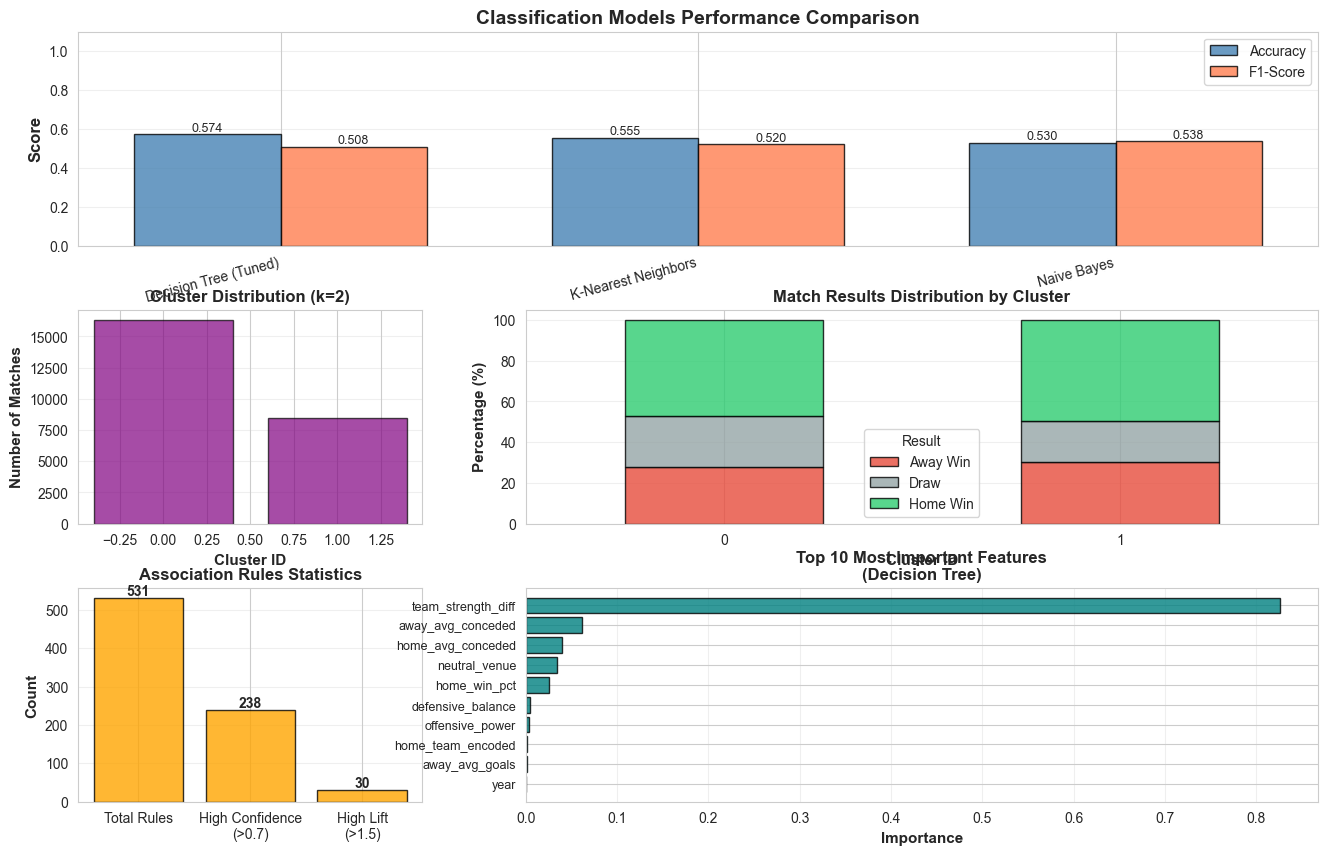

In [17]:
# ============================================================================
# STEP 17: MODEL PERFORMANCE SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("STEP 17: Comprehensive Performance Summary")
print("=" * 80)

# Create final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Classification model comparison
ax1 = fig.add_subplot(gs[0, :])
models = classification_comparison['Model']
x_pos = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, classification_comparison['Test Accuracy'], 
                width, label='Accuracy', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, classification_comparison['Test F1-Score'], 
                width, label='F1-Score', color='coral', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Classification Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Classification Models Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Cluster distribution
ax2 = fig.add_subplot(gs[1, 0])
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
ax2.bar(cluster_counts.index, cluster_counts.values, color='purple', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Matches', fontsize=11, fontweight='bold')
ax2.set_title(f'Cluster Distribution (k={optimal_k})', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Match result distribution by cluster
ax3 = fig.add_subplot(gs[1, 1:])
cluster_results = pd.crosstab(df['cluster'], df['match_result'], normalize='index') * 100
cluster_results.plot(kind='bar', stacked=True, ax=ax3, 
                     color=['#e74c3c', '#95a5a6', '#2ecc71'], alpha=0.8, edgecolor='black')
ax3.set_xlabel('Cluster ID', fontsize=11, fontweight='bold')
ax3.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax3.set_title('Match Results Distribution by Cluster', fontsize=12, fontweight='bold')
ax3.legend(['Away Win', 'Draw', 'Home Win'], title='Result')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.grid(axis='y', alpha=0.3)

# Association rules statistics
ax4 = fig.add_subplot(gs[2, 0])
rule_stats = pd.DataFrame({
    'Metric': ['Total Rules', 'High Confidence\n(>0.7)', 'High Lift\n(>1.5)'],
    'Count': [len(rules), len(rules[rules['confidence'] > 0.7]), len(rules[rules['lift'] > 1.5])]
})
bars = ax4.bar(rule_stats['Metric'], rule_stats['Count'], color='orange', alpha=0.8, edgecolor='black')
ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
ax4.set_title('Association Rules Statistics', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Feature importance from Decision Tree
ax5 = fig.add_subplot(gs[2, 1:])
feature_imp = pd.DataFrame({
    'Feature': X_scaled_df.columns,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

ax5.barh(range(len(feature_imp)), feature_imp['Importance'], color='teal', alpha=0.8, edgecolor='black')
ax5.set_yticks(range(len(feature_imp)))
ax5.set_yticklabels(feature_imp['Feature'], fontsize=9)
ax5.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax5.set_title('Top 10 Most Important Features\n(Decision Tree)', fontsize=12, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

plt.savefig('comprehensive_summary.png', dpi=300, bbox_inches='tight')
plt.show()